### Monopólios Esportivos

**​A Pergunta:** Quais esportes são dominados por um único país?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Inicia criando o data frame que vai ler os dados dos atletas

In [2]:
df_atleta = pd.read_csv('athlete_events_arrumado.csv', encoding='utf-8')
df_atleta['Medal'] = df_atleta['Medal'].fillna('0')
display(df_atleta.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,0


Agrupa os paises a partir do NOC e do esporte, contando a quantidade de medalhas de cada tipo (Ouro, Prata, Bronze) e preenchendo os valores faltantes (quem não tem medalha) com 0  e em seguida, agrupa usando o NOC e o sport para contar o número total de atletas para poder criar um novo data frame que vai unir o data frame com a quatidade de medalhas de cada tipo e o total de atletas.

In [3]:
df_medalhas = df_atleta.groupby(['NOC', 'Sport'])['Medal'].value_counts().unstack(fill_value=0) 

df_total = df_atleta.groupby(['NOC', 'Sport']).size().reset_index(name='Total_Atletas') 

df_simples = pd.merge(df_total, df_medalhas, on=['NOC', 'Sport'])

display(df_simples.head())
display(df_total.head())
display(df_medalhas.head())

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver
0,AFG,Athletics,22,22,0,0,0
1,AFG,Boxing,5,5,0,0,0
2,AFG,Football,11,11,0,0,0
3,AFG,Hockey,39,39,0,0,0
4,AFG,Judo,3,3,0,0,0


,NOC,Sport,Total_Atletas
0,AFG,Athletics,22
1,AFG,Boxing,5
2,AFG,Football,11
3,AFG,Hockey,39
4,AFG,Judo,3


Medal           0  Bronze  Gold  Silver
NOC Sport                              
AFG Athletics  22       0     0       0
    Boxing      5       0     0       0
    Football   11       0     0       0
    Hockey     39       0     0       0
    Judo        3       0     0       0

Cria um dataframe que vai receber o agrupamento de países a partir do NOC, isso vai fazer com que cada país seja uma única linha, e as colunas de Total_Atletas, Gold, Silver e Bronze sejam somadas para cada país. Depois, seleciona os 15 paises que mais levaram atletas e em seguida cria o gráfico usando os países no x, a quantidade no y para analisar o Total_Atletas e cada tipo de medalha.

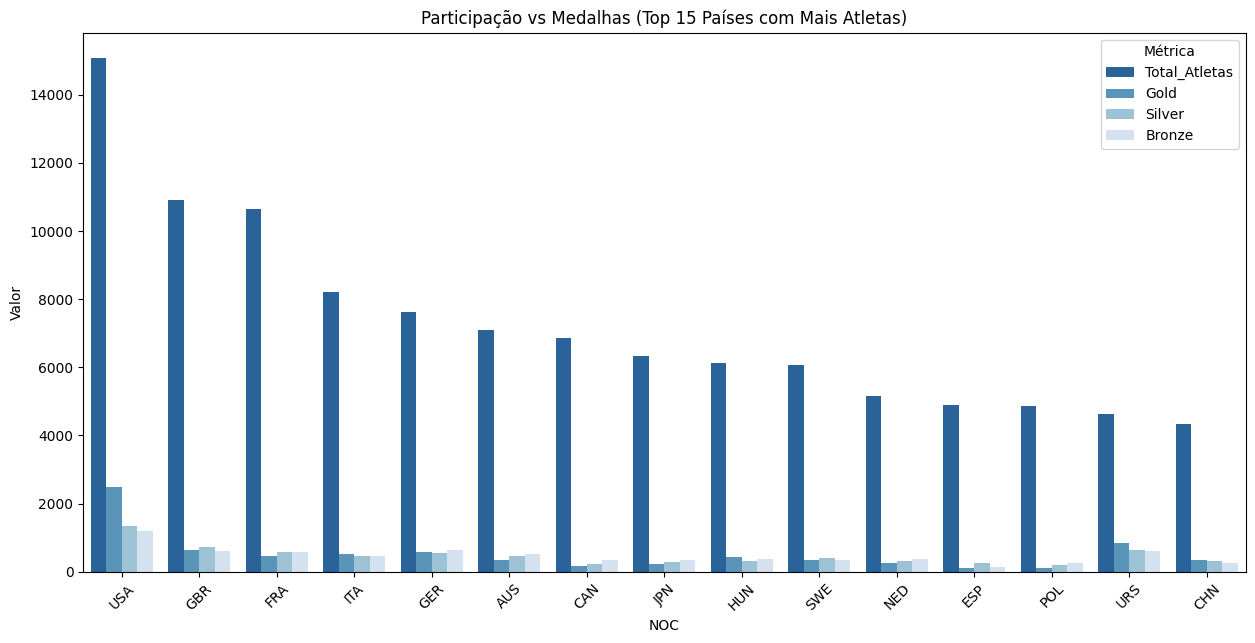

In [ ]:
df_agrupado = df_simples.groupby('NOC').agg({
    'Total_Atletas': 'sum',
    'Gold': 'sum',
    'Silver': 'sum',
    'Bronze': 'sum'
}).reset_index()

df_top = df_agrupado.nlargest(15, 'Total_Atletas')

df_plot = df_top.melt(id_vars=['NOC'], 
                      value_vars=['Total_Atletas', 'Gold', 'Silver', 'Bronze'],
                      var_name='Métrica', 
                      value_name='Valor')

plt.figure(figsize=(15, 7))
sns.barplot(data=df_plot, x='NOC', y='Valor', hue='Métrica', palette='Blues_r')
plt.title('Participação vs Medalhas (Top 15 Países com Mais Atletas)')
plt.xticks(rotation=45) 
plt.show()

Relação entre Total de Atletas e Medalhas

Cria um gráfico de dispersão para cada par de variáveis. (Sem a paleta que usamos pois ia ficar confuso de visualizar)

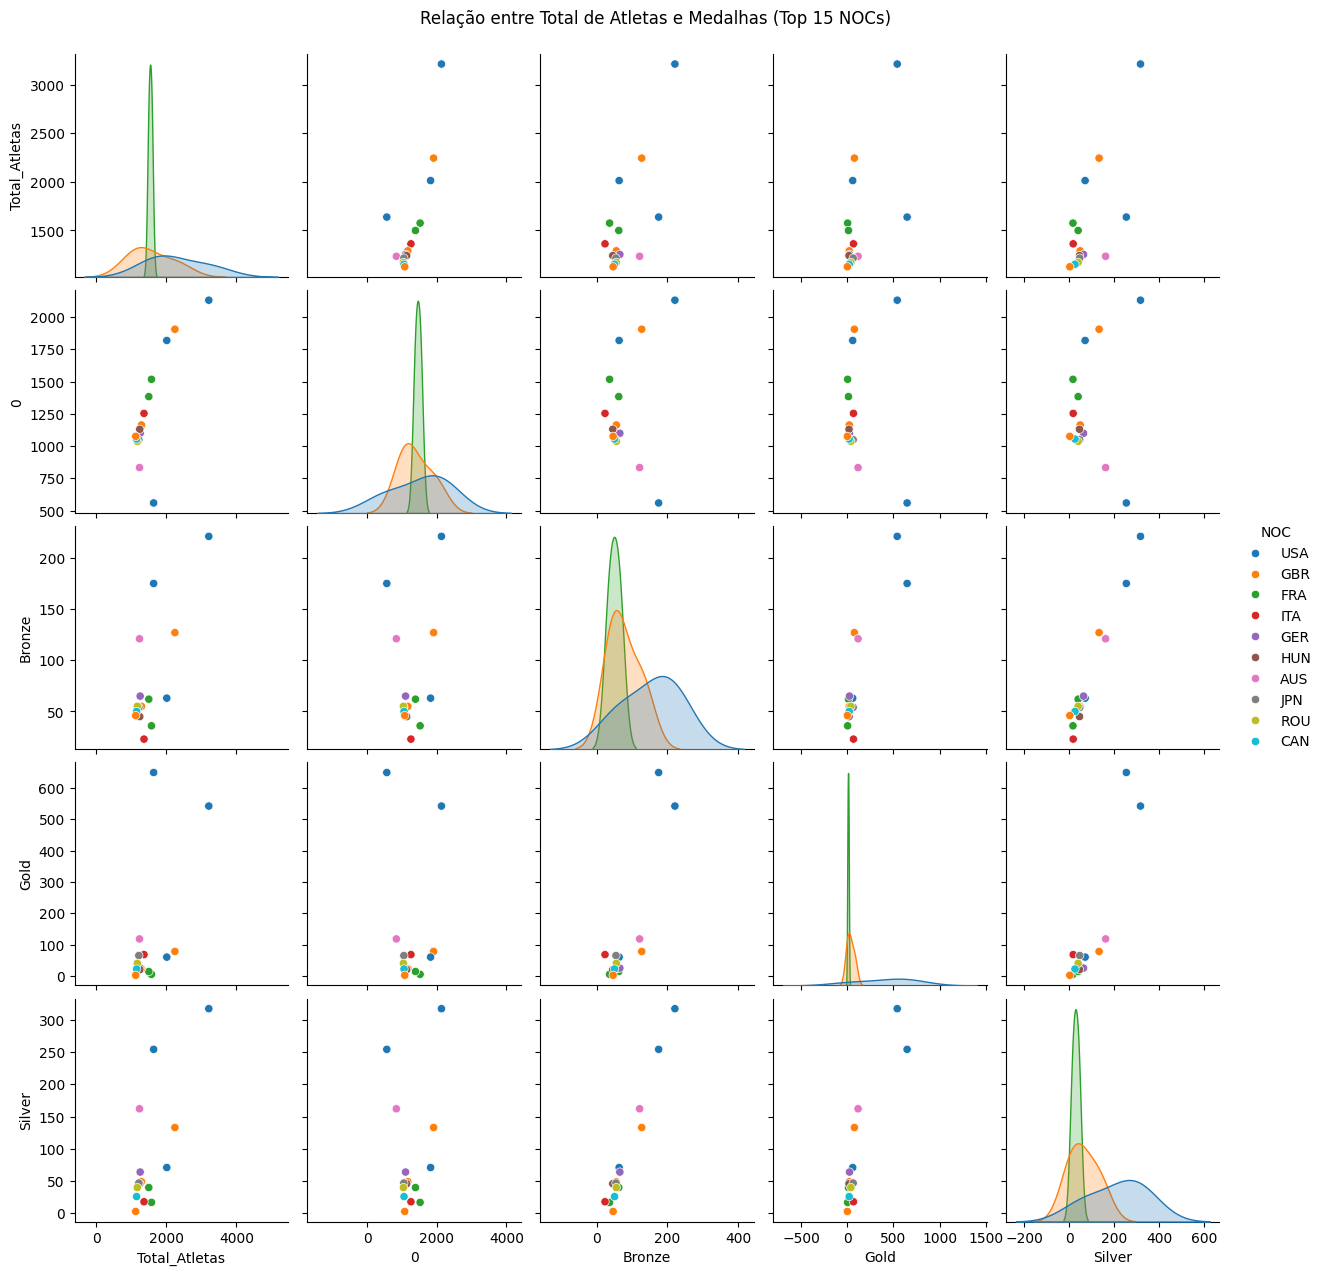

In [32]:
sns.pairplot(data=df_top, hue="NOC") 
plt.suptitle('Relação entre Total de Atletas e Medalhas (Top 15 NOCs)', y=1.02)
plt.show()

Os gráficos que cortam a diagonal principal são estimativas de densidade (KDE). Eles mostram onde os dados de cada país se concentram. Picos altos e estreitos significam que os números são consistentes, pois o eixo Y mostra que o valor é frequente e o eixo X curto indica baixa variância. Já uma curva baixa no Y ocorre porque existem resultados diferentes a cada registro, e se ela for larga no X, indica alta variância. No caso da França (verde), a partir das análises, podemos ver que ela é constante quanto às medalhas, enquanto o azul (EUA) é mais inconstante e variável.

Nos gráficos de dispersão (todos os outros), analisamos a correlação entre as variáveis. Percebemos que o Total de atletas é a principal variável das medalhas (mais atletas = mais medalhas); a inclinação dos pontos representa a eficácia de um país. A maioria dos países fica agrupada, o que significa que têm desempenho similar. Os EUA se destacam como um outlier constante, mantendo uma trajetória de crescimento que se distancia das demais potências conforme o volume de atletas aumenta

##### Em qual esporte cada pais mais tem medalhas?

Cria uma nova coluna que tem o total de medalhas no geral, após isso busca o esporte com mais medalhas de cada país. Calcula taxa de sucesso do esporte com mais medalhas usando a formula: $$Eficiência = \left( \frac{\text{Total de Medalhas}}{\text{Total de Atletas}} \right) \times 100$$
Ordena pelos 20 paises que mais tem medalhas.

In [ ]:
df_simples['Total_Medalhas'] = df_simples['Gold'] + df_simples['Silver'] + df_simples['Bronze']

idx = df_simples.groupby('NOC')['Total_Medalhas'].idxmax()
df_destaque = df_simples.loc[idx, ['NOC', 'Sport', 'Total_Medalhas', 'Total_Atletas']]

df_destaque['Eficiencia_%'] = (df_destaque['Total_Medalhas'] / df_destaque['Total_Atletas'] * 100).round(2)

display(df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20))

,NOC,Sport,Total_Medalhas,Total_Atletas,Eficiencia_%
3134,USA,Athletics,1080,3211,33.63
169,AUS,Swimming,401,1235,32.47
1590,ITA,Fencing,359,736,48.78
1120,GBR,Athletics,338,2244,15.06
1045,FRA,Fencing,310,982,31.57
3096,URS,Gymnastics,288,797,36.14
2136,NED,Hockey,255,418,61.00
1390,HUN,Fencing,236,628,37.58
1231,GER,Rowing,236,526,44.87
509,CAN,Rowing,203,559,36.31


Pega os primeiros 20 paises que mais tem medalhas por esporte, cria uma coluna que tem o nome do país e o esporte que ele mais se destacou este sera o y do grafico que vamos criar. Criamos o gráfico usando a coluna que criamos no y e o total de medlahas no x e em seguida um for que vai mostrar a eficiencia no final da barra de cada pais e seu esporte de maior numero de medalhas. 

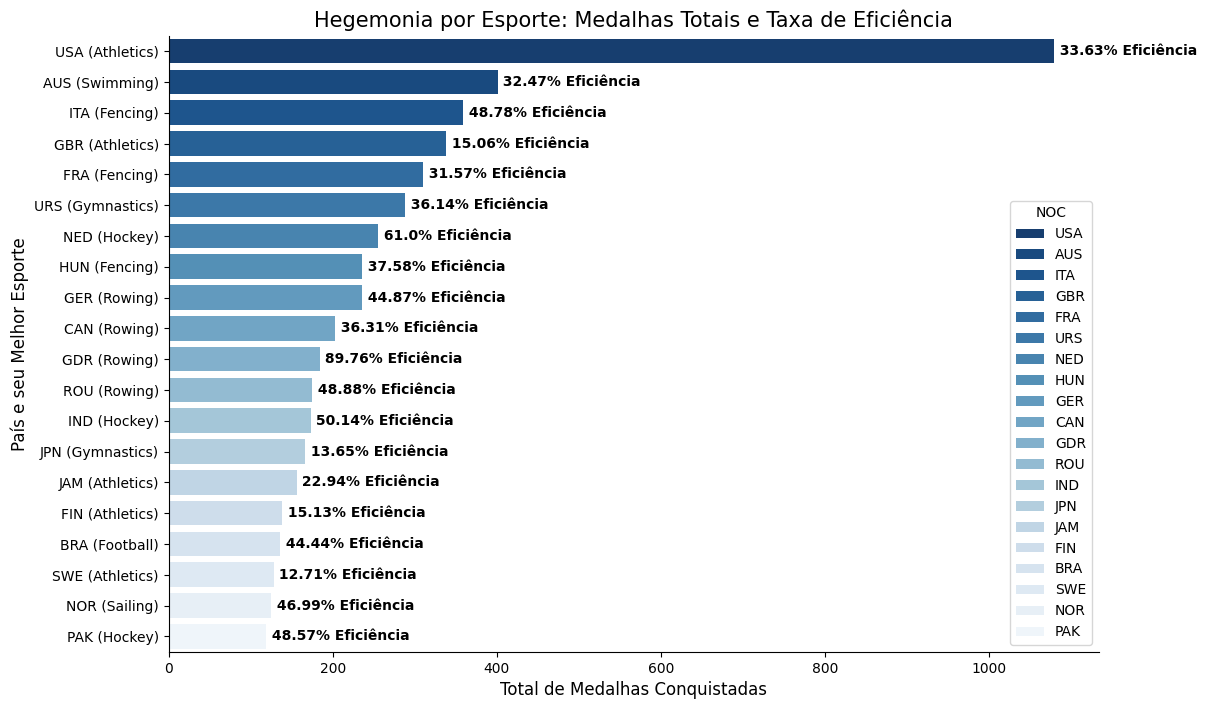

In [51]:
df_plot = df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20).copy() 
df_plot['Label'] = df_plot['NOC'] + ' (' + df_plot['Sport'] + ')' 

plt.figure(figsize=(12, 8))

ax = sns.barplot(data=df_plot, x='Total_Medalhas', y='Label', hue='NOC', palette='Blues_r')

for i, (medals, eff) in enumerate(zip(df_plot['Total_Medalhas'], df_plot['Eficiencia_%'])):
    ax.text(medals + 1, i, f' {eff}% Eficiência', va='center', fontweight='bold', color='black')

plt.title('Hegemonia por Esporte: Medalhas Totais e Taxa de Eficiência', fontsize=15)
plt.xlabel('Total de Medalhas Conquistadas', fontsize=12)
plt.ylabel('País e seu Melhor Esporte', fontsize=12)
sns.despine()
plt.show()

##### Quais esportes tem mais medalhas?

Pega por sport o total de medalhas e ordena do maior para o menor, pegando os 15 primeiros, cria um grafico de barras que analiza o total de medalhas por esporte

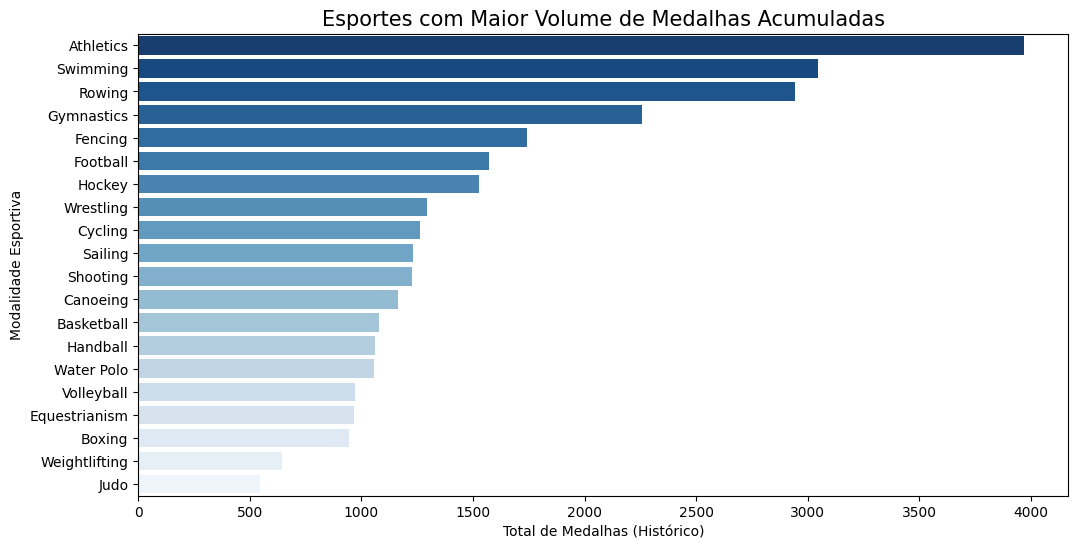

In [48]:
df_esportes_top = df_simples.groupby('Sport')['Total_Medalhas'].sum().nlargest(20).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, x='Total_Medalhas', y='Sport', hue='Sport', palette='Blues_r')

plt.title('Esportes com Maior Volume de Medalhas Acumuladas', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.show()

##### Quais esportes tem mais atletas?

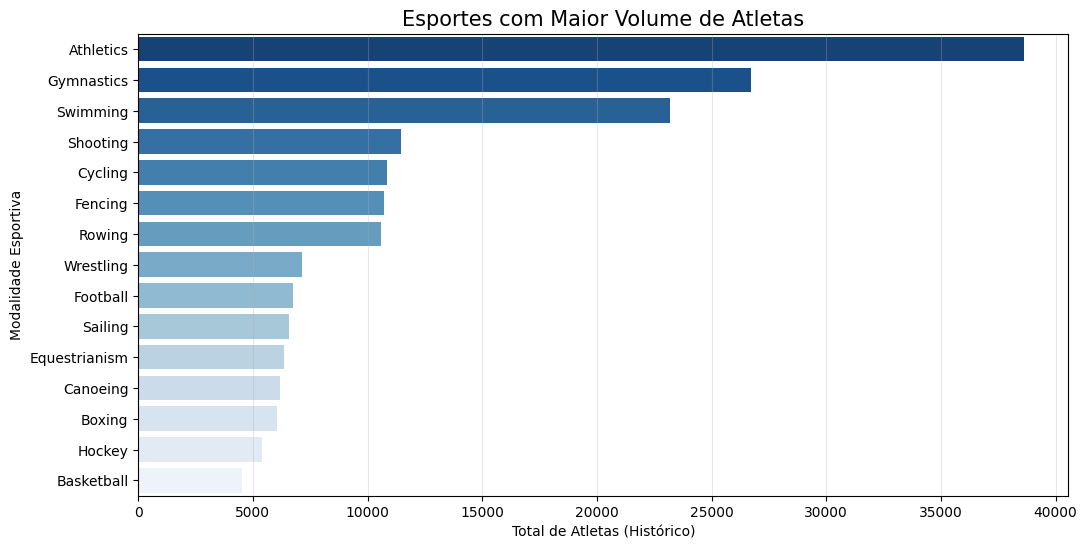

In [114]:
df_esportes_top = df_simples.groupby('Sport')['Total_Atletas'].sum().nlargest(15).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, x='Total_Atletas', y='Sport', hue='Sport', palette='Blues_r')

plt.title('Esportes com Maior Volume de Atletas', fontsize=15)
plt.xlabel('Total de Atletas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)
plt.show()

Analise do Brasil

C:\Users\maria\AppData\Local\Temp\ipykernel_3192\3610766312.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


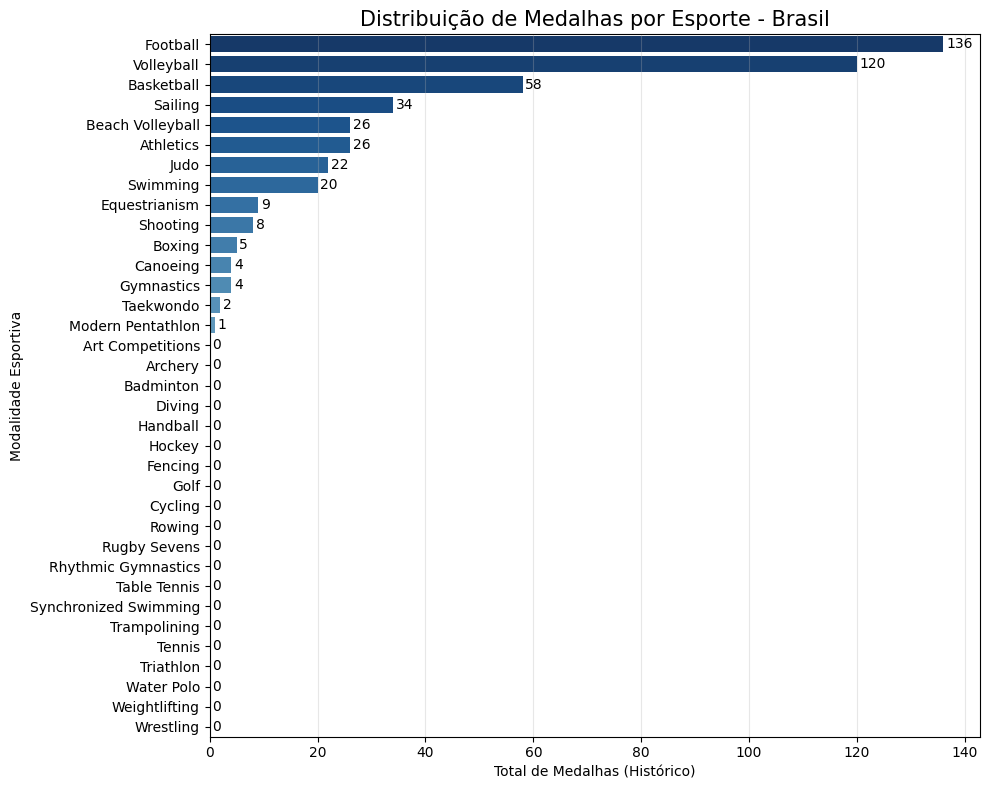

In [52]:
df_brasil = df_simples[df_simples['NOC'] == 'BRA']

# 2. Agrupar por esporte e somar as medalhas
df_bra_esportes = df_brasil.groupby('Sport')['Total_Medalhas'].sum().sort_values(ascending=False).reset_index()

# 3. Criar o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_bra_esportes, 
    x='Total_Medalhas', 
    y='Sport', 
    palette='Blues_r' 
)

plt.title('Distribuição de Medalhas por Esporte - Brasil', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(df_bra_esportes['Total_Medalhas']):
    plt.text(v + 0.5, i, str(int(v)), color='black', va='center')

plt.tight_layout()
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_3192\2676758298.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


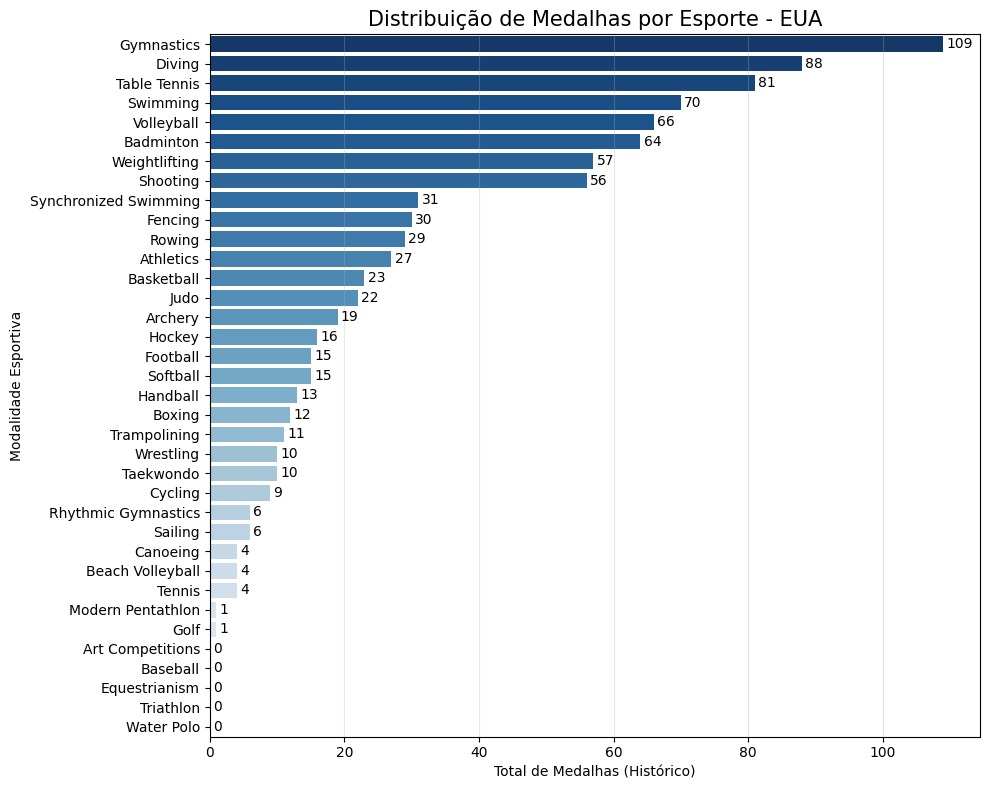

In [62]:
df_brasil = df_simples[df_simples['NOC'] == 'CHN']

# 2. Agrupar por esporte e somar as medalhas
df_bra_esportes = df_brasil.groupby('Sport')['Total_Medalhas'].sum().sort_values(ascending=False).reset_index()

# 3. Criar o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_bra_esportes, 
    x='Total_Medalhas', 
    y='Sport', 
    palette='Blues_r'
)

plt.title('Distribuição de Medalhas por Esporte - EUA', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(df_bra_esportes['Total_Medalhas']):
    plt.text(v + 0.5, i, str(int(v)), color='black', va='center')

plt.tight_layout()
plt.show()

#### Qual a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas?

Primeiro, calcula o total de ouros por esporte de todas as medalhas de ouro dadas e calcula os ouros agrupando por pais e esportes para calcular a porcentagem da dominancia usando a formula e evida divisao por zero: $$Dominância = \left( \frac{\text{Total de Ouros do País no Esporte}}{\text{Total de Ouros Históricos do Esporte}} \right) \times 100$$ depois filtra para pegar apenas os esportes com mais de 10 ouros totais e países com pelo menos 3 ouros para evitar um gráfico muito vazio.

In [ ]:
df_calc = df_simples.copy()

total_ouros_esporte = df_calc.groupby('Sport')['Gold'].sum()

df_dominancia = df_calc.groupby(['NOC', 'Sport'])['Gold'].sum().reset_index()

df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Gold'] / total_ouros_esporte[x['Sport']] * 100) 
    if total_ouros_esporte[x['Sport']] > 0 else 0, axis=1
)

esportes_vivos = total_ouros_esporte[total_ouros_esporte > 10].index
df_plot = df_dominancia[
    (df_dominancia['Sport'].isin(esportes_vivos)) & 
    (df_dominancia['Gold'] >= 3)
].copy()

Cria o gráfico, que vai mostrar as 15 primeiras dominancias, usando no eixo x a dominancia e no y o esporte. Cria um for que vai adicionar o valor da dominancia em porcentagem no final de cada barra.

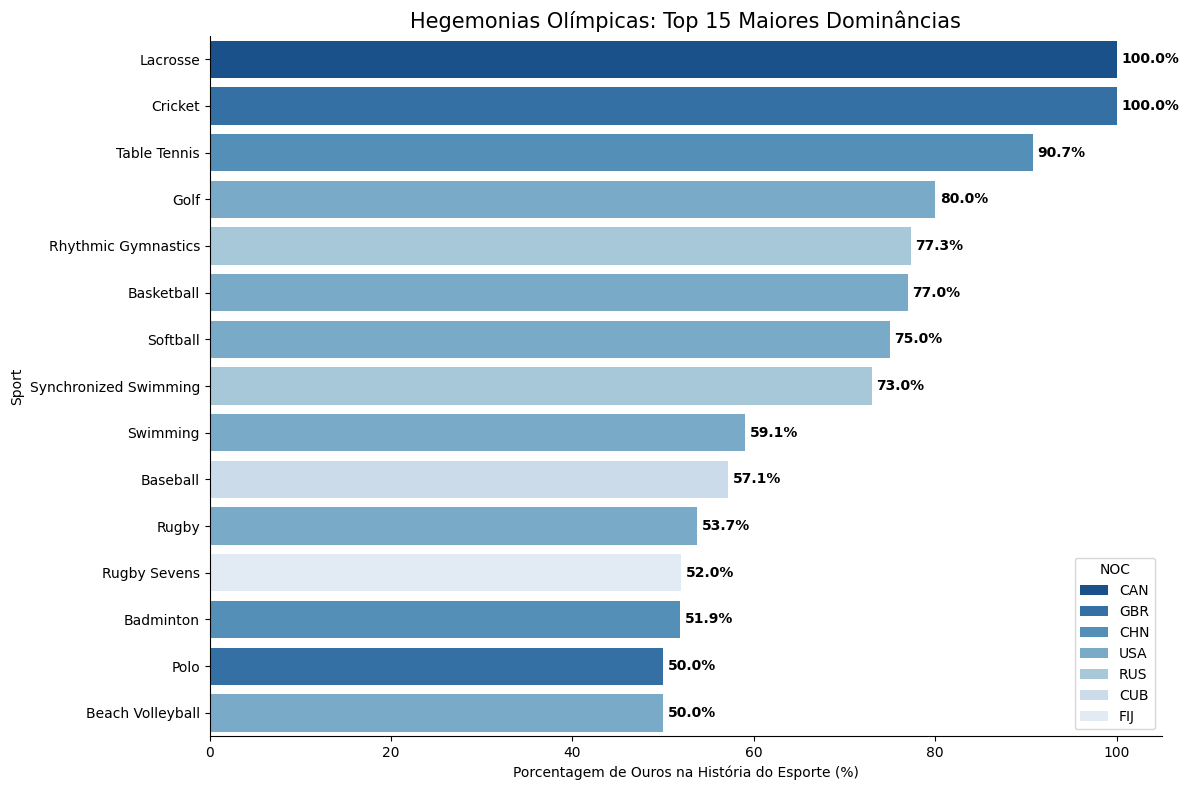

In [ ]:
df_plot = df_plot.sort_values('Dominancia_%', ascending=False).head(15)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot, 
    x='Dominancia_%', 
    y='Sport', 
    hue='NOC', 
    dodge=False,
    palette='Blues_r'
)

plt.title('Hegemonias Olímpicas: Top 15 Maiores Dominâncias', fontsize=15)
plt.xlabel('Porcentagem de Ouros na História do Esporte (%)')

for i, v in enumerate(df_plot['Dominancia_%']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

Brasill

C:\Users\maria\AppData\Local\Temp\ipykernel_17944\2391000588.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


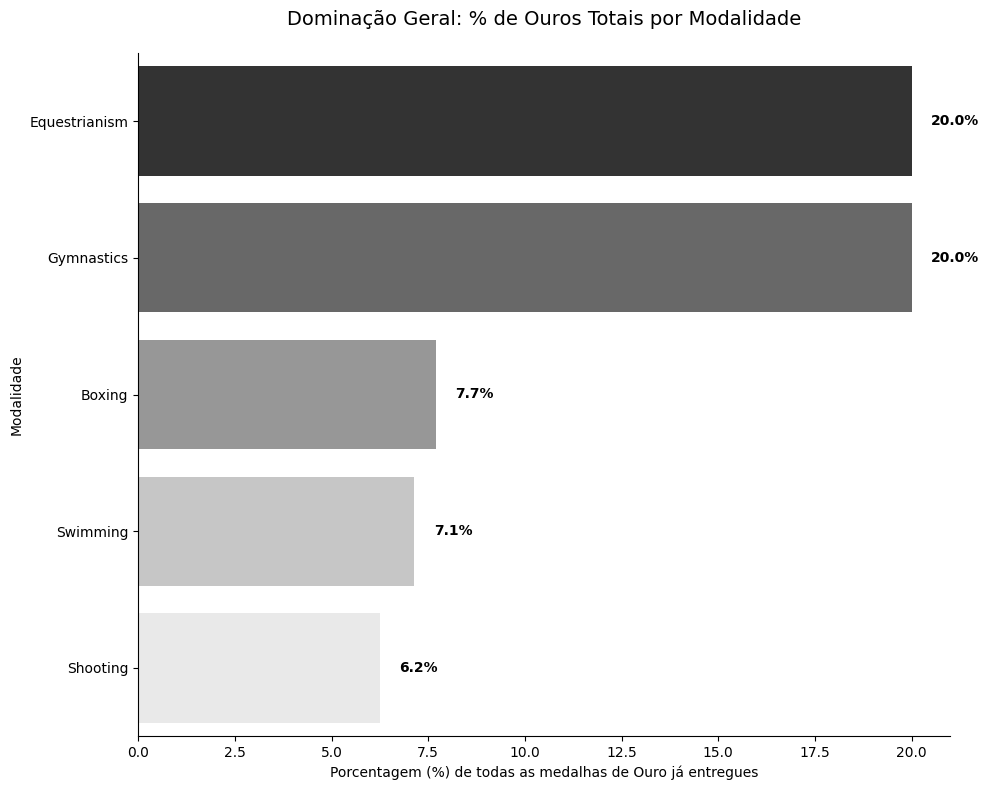

In [134]:
# 1. Filtrar apenas medalhas de Ouro
df_ouros = df_simples[df_simples['Gold'] == 1]

# 2. Calcular o total de ouros por esporte (no mundo todo)
total_ouros_esporte = df_ouros.groupby('Sport')['Gold'].count()

# 3. Calcular ouros por País e Esporte
df_dominancia = df_ouros.groupby(['NOC', 'Sport'])['Gold'].count().reset_index()

# 4. Calcular a Porcentagem (%)
df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Gold'] / total_ouros_esporte[x['Sport']]) * 100, axis=1
)

# 5. Filtrar para o Brasil (ou o país que desejar)
df_brasil_dom = df_dominancia[df_dominancia['NOC'] == 'BRA'].sort_values('Dominancia_%', ascending=False)
plt.figure(figsize=(10, 8))

# Usando o degradê de cinzas/preto para um visual "Premium"
sns.barplot(
    data=df_brasil_dom.head(), # Top 10 esportes dominados
    x='Dominancia_%', 
    y='Sport', 
    palette='Greys_r'
)

plt.title('Dominação Geral: % de Ouros Totais por Modalidade', fontsize=14, pad=20)
plt.xlabel('Porcentagem (%) de todas as medalhas de Ouro já entregues')
plt.ylabel('Modalidade')

# Adicionando o símbolo de % nas barras
for i, v in enumerate(df_brasil_dom.head()['Dominancia_%']):
    plt.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [130]:


# 1. Calcular o total de ouros que cada esporte já entregou no mundo todo
total_ouros_esporte = df_simples.groupby('Sport')['Gold'].sum()

# 2. Criar o DataFrame de dominância
# Pegamos o somatório de Gold por País e Esporte
df_dom = df_simples.groupby(['NOC', 'Sport'])['Gold'].sum().reset_index()

# 3. Calcular a porcentagem (%)
# O lambda vai buscar o total do esporte no mapa que criamos no passo 1
df_dom['Dominancia_%'] = df_dom.apply(
    lambda x: (x['Gold'] / total_ouros_esporte[x['Sport']] * 100) 
    if total_ouros_esporte[x['Sport']] > 0 else 0, axis=1
)


C:\Users\maria\AppData\Local\Temp\ipykernel_17944\3555078616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


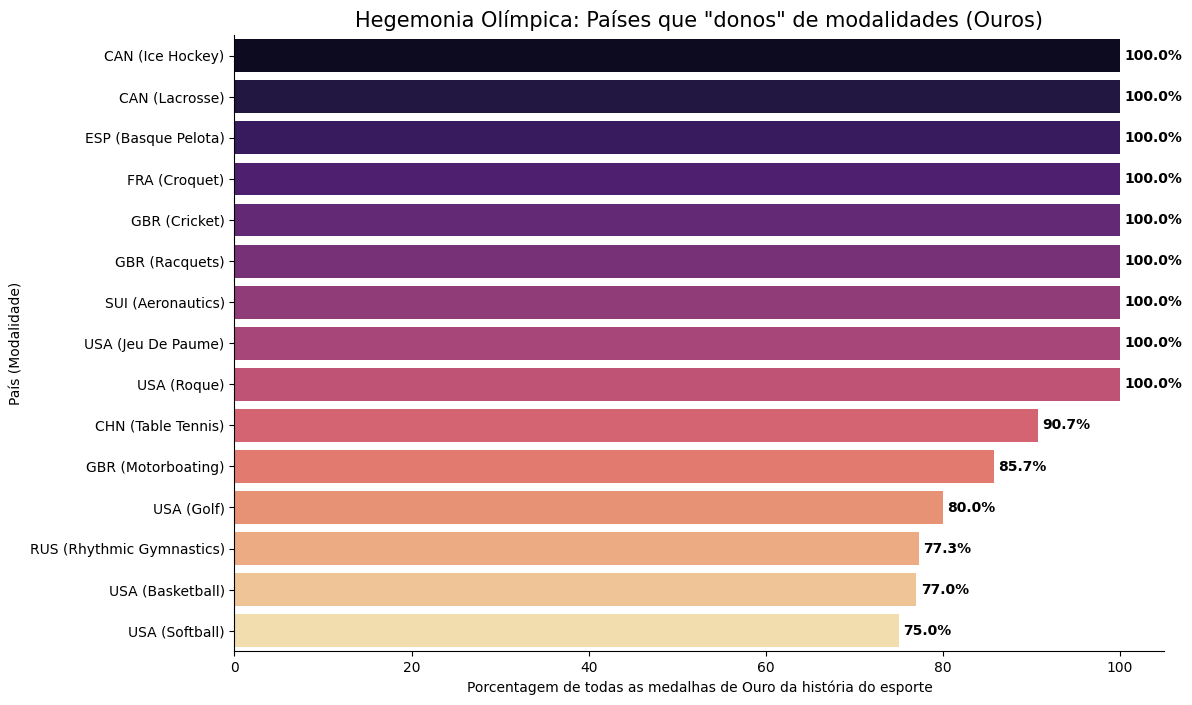

In [131]:
# 4. Criar identificador e pegar o Top 15
df_dom['Label'] = df_dom['NOC'] + " (" + df_dom['Sport'] + ")"
top_15_geral = df_dom.nlargest(15, 'Dominancia_%')

# 5. Gráfico com degradê coeso
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_geral, 
    x='Dominancia_%', 
    y='Label', 
    palette='magma' # Degradê do preto/roxo ao dourado
)

plt.title('Hegemonia Olímpica: Países que "donos" de modalidades (Ouros)', fontsize=15)
plt.xlabel('Porcentagem de todas as medalhas de Ouro da história do esporte')
plt.ylabel('País (Modalidade)')

# Adiciona o valor na frente da barra
for i, v in enumerate(top_15_geral['Dominancia_%']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.despine()
plt.show()